In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os
import scipy
import sys

sys.path.append('../../Share')
import shared_iENG_sENG
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

# iENG - invasive

- feature set : 이미 있음
- zc, ssc, wl, wilson amplitude, mav, msq, RMS, V3, log detector, Difference absolute standard deviation, Maximum fractal length, Myopulse percentage rate, Mean absolute value slope, Weighted mean absolute
- commons: MAV, wamp, SSC, ZC, WL, RMS = idx: [0,1,2,3,4,6]

In [ ]:
def get_iENG(gesture_label, feature_set):
    path = 'C:/Users/hml76/Desktop/Jupyter/Federated Prototype Learning/Dataset/Ours_cleaned/'
    fname = os.listdir(path)
    iENG_subjects = {"subject2": {"X": [], "Y": []}, "subject3": {"X": [], "Y": []}}

    for f in fname:
        for i in range(10):
            X = np.array(pd.read_csv(path + f'{f}/rep{i}_X.csv'))
            y = np.array(pd.read_csv(path + f'{f}/rep{i}_Y.csv'))
            #indices = np.random.permutation(len(X)) # shuffle
            #X, y = X[indices], y[indices]

            y_int = np.argmax(y, axis=1)
            num_classes = np.max(y_int) + 1

            if "subject2" in f:
                iENG_subjects["subject2"]["X"].append(X)
                iENG_subjects["subject2"]["Y"].append(y_int)
            elif "subject3" in f:
                iENG_subjects["subject3"]["X"].append(X)
                iENG_subjects["subject3"]["Y"].append(y_int)

    final_session = 4
    y = iENG_subjects["subject2"]['Y'][2:final_session] + iENG_subjects["subject3"]['Y'][2:final_session]
    x = iENG_subjects["subject2"]['X'][2:final_session] + iENG_subjects["subject3"]['X'][2:final_session]

    y = np.concatenate(y, axis=0)
    x = np.concatenate(x, axis=0)
    x = x.reshape(x.shape[0], 16, 14)

    x = x[:, [0, 4, 8, 12], :][:, :, feature_set]   # (N, 4, 5)
    x = x.reshape(x.shape[0], -1)           # (N, 20)
    # others => [0, 2, 3, 4, 12] # ZC, WL, WAMP, MAV, MAVS

    #mask = (y == 0)
    #mask = (y >= 1) & (y <= 5)
    mask = (y == gesture_label)
    iENG_x_zero = x[mask]
    iENG_y_zero = y[mask]
    print(iENG_x_zero.shape, iENG_y_zero.shape)

    return iENG_x_zero, iENG_y_zero

# sEMG
- commons: MAV, wamp, SSC, ZC, WL, RMS
- 11TD features = idx: [0,1,2,3] = MAV, WL, WAMP, ZC
- 9 TD features = idx: [1,2] = SSC, RMS
- gesture_label1, gesture_label2로 나눈 이유: Ninapro 에서는 접고 / 펴는게 각각 gesture로 되어있어서 일부러 2개로 함

In [ ]:
import re
from sklearn.preprocessing import OneHotEncoder

def Error_in_Y(Y_dataset):
    new_Y = []
    for i in range(len(Y_dataset)):
        decoded_string = str(Y_dataset[i])
        match = re.search(r'\(\d+, (\d+)\)', decoded_string)

        if match:
            extracted_value = int(match.group(1))
            new_Y.append(extracted_value)

        else: print("Error")

    labels = np.array(new_Y).reshape(-1, 1)

    encoder = OneHotEncoder(categories=[range(np.max(new_Y)+1)])
    one_hot_encoded = encoder.fit_transform(labels).toarray()

    return one_hot_encoded

def get_sEMG(b_path, sub_lst, g_label1, g_label2, f_idx, num_ch, num_feat, db):
    X_lst, y_lst = [], []

    for sub in sub_lst:
        for rep in range(1, 6):
            try:
                X = pd.read_csv(b_path + f'/Sub{sub}/Sub{sub}_Rep{rep}_data.csv')
                y = pd.read_csv(b_path + f'/Sub{sub}/Sub{sub}_Rep{rep}_label.csv')
            except:
                X = pd.read_csv(b_path + f'/Sub{sub}_serial/Sub{sub}_Rep{rep}_data.csv')
                y = pd.read_csv(b_path + f'/Sub{sub}_serial/Sub{sub}_Rep{rep}_label.csv')

            if db == "DB1_TD2" or db == "DB5_TD2":
                y = Error_in_Y(np.array(y))

            y = np.argmax(y, axis=1)
            mask = (y >= g_label1) & (y <= g_label2)
            X = np.array(X).reshape(X.shape[0], num_ch, num_feat)
            #print(X.shape)

            feature_idx = np.atleast_1d(f_idx)
            X = X[:, [2,6,8,0], :][:, :, feature_idx]
            #print("After selection:", X.shape)  # (11944, 4, 5)

            # optional flatten
            X = X.reshape(X.shape[0], -1)
            #print("After flatten:", X.shape)  # (11944, 20)

            X_lst.append(X[mask])
            y_lst.append(y[mask])

    sEMG_x = np.concatenate(X_lst, axis=0)
    sEMG_y = np.concatenate(y_lst, axis=0)

    print(sEMG_x.shape, sEMG_y.shape)
    return sEMG_x, sEMG_y

# sENG
- feature ready
- 14 features
- commons: MAV, wamp, SSC, ZC, WL, RMS = idx: [0,1,2,3,4,6]

In [ ]:
def return_X_y_get_from_matfile(path, num_session, balance):
    data_per_class_files = os.listdir(path)
    X, y = [], []

    for f in num_session:
        for cls in data_per_class_files:
            input_path = path+cls+'/'
            files = os.listdir(input_path)
            mat = scipy.io.loadmat(input_path+files[f])
            labels = mat['Data_Cls'].reshape(-1)  # shape: (1, 1729)

            features = mat['Data_Fea']
            features = np.transpose(features, (2, 0, 1))  # shape: (1729, 4, 14)
            X.append(features)
            y.append(labels)

    X_train = np.concatenate(X, axis=0)
    y_train = np.concatenate(y, axis=0)
    X_train = X_train[:, :, :, np.newaxis]
    #print(pd.Series(y_train).value_counts())
    print(X_train.shape, y_train.shape)

    if balance:
        X_train, y_train = balance_data(X_train, y_train)

    return X_train, y_train




def get_sENG(gesture_label, feature_set):
    bluetooth_id = 'E9AD0E7DCC2B'
    base_path = 'C:/Users/hml76/PycharmProjects/MindForce/data/sENG_iENG/'
    X_sENG_sub1, y_sENG_sub1 = shared_iENG_sENG.return_X_y_get_from_matfile(path = base_path+f'Hunmin/{bluetooth_id}/raw/', num_session=[0,1,2,3,4], balance=True)
    X_sENG_sub2, y_sENG_sub2 = shared_iENG_sENG.return_X_y_get_from_matfile(path = base_path+f'Byeongchan/{bluetooth_id}/raw/', num_session=[0,1,2,3,4], balance=True)
    X_sENG_sub3, y_sENG_sub3 = shared_iENG_sENG.return_X_y_get_from_matfile(path = base_path+f'Minjeong/{bluetooth_id}/raw/', num_session=[0,1,2,3,4], balance=True)
    X_sENG, y_sENG = np.concatenate([X_sENG_sub1, X_sENG_sub2, X_sENG_sub3], axis=0), np.concatenate([y_sENG_sub1, y_sENG_sub2, y_sENG_sub3], axis=0)

    x, y = X_sENG, y_sENG

    #mask = (y == 0)
    #mask = (y >= 1) & (y <= 5)
    mask = (y == gesture_label)
    sENG_x_zero = x[mask]
    sENG_y_zero = y[mask]

    sENG_x_zero = sENG_x_zero[:, :, feature_set]
    sENG_x_zero = sENG_x_zero.reshape(sENG_x_zero.shape[0], 4*len(feature_set))

    print(sENG_x_zero.shape, sENG_y_zero.shape)
    return sENG_x_zero, sENG_y_zero

In [3]:
path = 'C:/Users/hml76/PycharmProjects/MindForce/data/sENG_iENG/Hunmin/E9AD0E7DCC2B/raw/'
data_per_class_files = os.listdir(path)
X, y = [], []
num_session = [0,1,2,3,4]

for f in num_session:
    for cls in data_per_class_files:
        input_path = path+cls+'/'
        files = os.listdir(input_path)
        mat = scipy.io.loadmat(input_path+files[f])
        #labels = mat['Data_Cls'].reshape(-1)  # shape: (1, 1729)
        #features = mat['Data_Fea']
        signal = mat['Data_ADC']

KeyError: 'raw'

In [7]:
mat['Data_ADC'].shape

(4, 214016)

In [9]:
mat.keys(), mat['Dev_Info']

(dict_keys(['__header__', '__version__', '__globals__', 'Data_ADC', 'Data_Cls', 'Data_Fea', 'Dev_Channels', 'Dev_Info', 'Dev_NCh']),
 array([[(array(['2C8041F7C8C356AA'], dtype='<U16'), array(['E9AD0E7DCC2B'], dtype='<U12'), array(['1.0.6'], dtype='<U5'), array(['1.0.4'], dtype='<U5'), array(['1.0.4'], dtype='<U5'))]],
       dtype=[('uuid', 'O'), ('sn', 'O'), ('mcu_firmware', 'O'), ('fpga_firmware', 'O'), ('receiver_firmware', 'O')]))

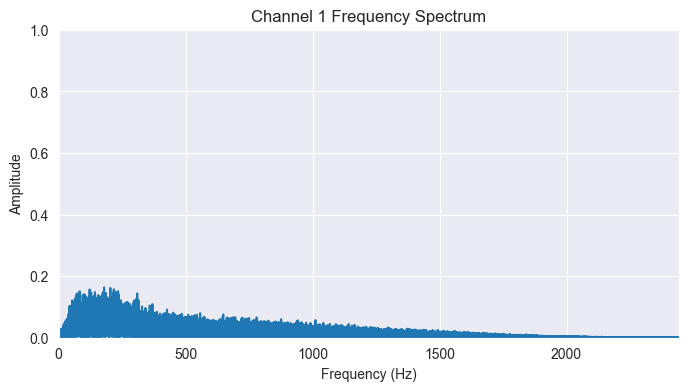

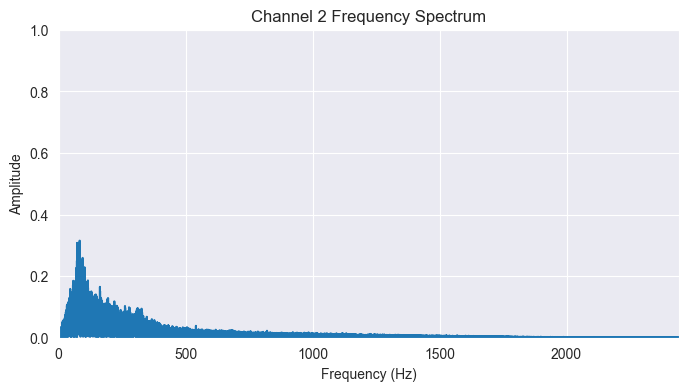

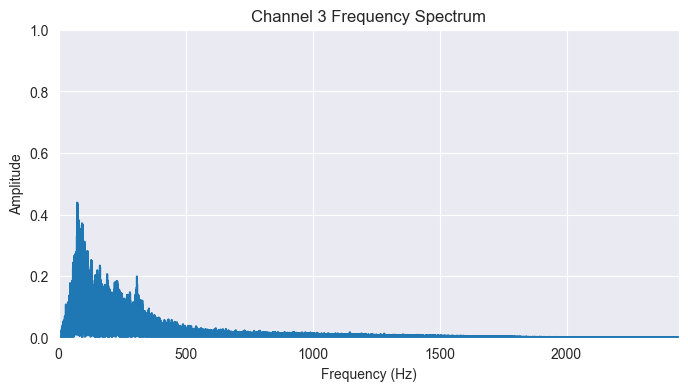

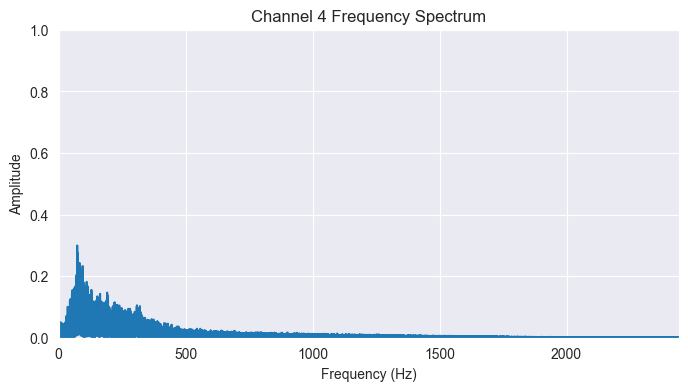

In [12]:
import numpy as np
import matplotlib.pyplot as plt

fs = round(10e6 / 2048)  # 4883 Hz

# FFT for each channel
data = mat['Data_ADC']
for ch in range(data.shape[0]):
    signal = data[ch]

    # Apply FFT
    N = len(signal)
    freqs = np.fft.rfftfreq(N, d=1/fs)      # frequency axis
    fft_vals = np.fft.rfft(signal)          # complex values
    magnitude = np.abs(fft_vals) / N        # amplitude spectrum

    # Plot the frequency spectrum
    plt.figure(figsize=(8, 4))
    plt.plot(freqs, magnitude)
    plt.title(f'Channel {ch+1} Frequency Spectrum')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.ylim(0, 1)
    plt.xlim(0, fs/2)
    plt.grid(True)
    plt.show()

In [ ]:
#features = np.transpose(features, (2, 0, 1))  # shape: (1729, 4, 14)
        #X.append(features)
        #y.append(labels)

X_train = np.concatenate(X, axis=0)
y_train = np.concatenate(y, axis=0)
X_train = X_train[:, :, :, np.newaxis]
#print(pd.Series(y_train).value_counts())
print(X_train.shape, y_train.shape)

if balance:
    X_train, y_train = balance_data(X_train, y_train)

return X_train, y_train

- Target class: 한손가락씩 접었다가 펴는거 or resting state
- Exercise A만 가능 : DB1, DB4, DB5

In [ ]:
TD1_path_DB1 = 'C:/Users/hml76/Desktop/Jupyter/Federated Prototype Learning/Dataset/DB1'
TD1_path_DB4 = 'C:/Users/hml76/Desktop/Jupyter/Federated Prototype Learning/Dataset/DB4'
TD1_path_DB5 = 'C:/Users/hml76/Desktop/Jupyter/Federated Prototype Learning/Dataset/DB5'
TD2_path_DB1 = 'C:/Users/hml76/Desktop/Jupyter/Generalization - EMG/new_features_data/DB1_TD2'
TD2_path_DB4 = 'C:/Users/hml76/Desktop/Jupyter/Generalization - EMG/new_features_data/DB4_TD2'
TD2_path_DB5 = 'C:/Users/hml76/Desktop/Jupyter/Generalization - EMG/new_features_data/DB5_TD2'
# Index finger : class 1-2 / Middle finger : class 3-4 / Ring finger : class 5-6 / Pinky finger : class 7-8 / Thumb : class 9-10  or  11-12

f_idx_TD1 = [0,1,2,3] #MAV, WL, WAMP, ZC
f_idx_TD2 = [1,2]  #SSC, RMS
DB1_channels, DB4_channels, DB5_channels = 10, 12, 16
TD1_features, TD2_features, TD2_features_DB4 = 11, 8, 10

- commons: MAV, wamp, SSC, ZC, WL, RMS, MAVS = idx: [0,1,2,3,4,6,12] => iENG, sENG
##### zc, ssc, wl, wilson amplitude, mav, msq, RMS, V3, log detector, Difference absolute standard deviation, Maximum fractal length, Myopulse percentage rate, Mean absolute value slope, Weighted mean absolute
#### sEMG
- 11TD features = idx: [0,1,2,3] = MAV, WL, WAMP, ZC
- 9 TD features = idx: [1,2] = SSC, RMS

In [ ]:
from scipy.stats import wilcoxon, mannwhitneyu

def summarize_features(X):
    """
    X: (samples, channels)
    return: feature별 mean, std, median 등
    """
    return {
        "mean": np.mean(X, axis=0),
        "std": np.std(X, axis=0),
        "median": np.median(X, axis=0)
    }


def compare_modalities(X1, X2, test_type="wilcoxon"):
    """
    Compare two modalities feature-wise.
    Returns: list of p-values per channel
    """
    p_values = []
    for ch in range(X1.shape[1]):
        try:
            if test_type == "wilcoxon":
                stat, p = wilcoxon(X1[:, ch], X2[:, ch])
            else:
                stat, p = mannwhitneyu(X1[:, ch], X2[:, ch])
        except ValueError:
            p = np.nan  # if not enough samples
        p_values.append(p)
    return np.array(p_values)


def plot_feature_boxplot(iENG_X, sENG_X, sEMG_X, feature_name):
    """
    feature_name: e.g., 'MAV', 'ZC', etc.
    """
    data = [iENG_X.flatten(), sENG_X.flatten(), sEMG_X.flatten()]
    labels = ['iENG', 'sENG', 'sEMG']

    plt.figure(figsize=(6,4))
    plt.boxplot(data, labels=labels, showmeans=True)
    plt.title(f'Feature Distribution Comparison: {feature_name}')
    plt.ylabel('Feature Value')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

def sample_match(X_ref, X_target):
    n = min(len(X_ref), len(X_target))
    idx = np.random.choice(len(X_target), n, replace=False)
    return X_target[idx]

from scipy.stats import mannwhitneyu

def compare_feature_distributions(X1, X2, name1, name2):
    p_values = []
    for ch in range(X1.shape[1]):  # channel-wise comparison
        X1_ch = X1[:, ch]
        X2_ch = X2[:, ch]
        stat, p = mannwhitneyu(X1_ch, X2_ch, alternative='two-sided')
        p_values.append(p)
        print(f"{name1} vs {name2} - Channel {ch+1}: p = {p:.4f}")
    return np.array(p_values)


def compute_avg_channel_distance(sENG, iENG, sEMG_list):
    """
    Compute average Euclidean distance between sENG, iENG, and multiple sEMG datasets.
    Channel-wise values are averaged for each sample.

    Args:
        sENG: np.array of shape (n_samples_sENG, n_channels)
        iENG: np.array of shape (n_samples_iENG, n_channels)
        sEMG_list: list of np.array, each with shape (n_samples, n_channels)

    Returns:
        dict: distances between sENG-iENG and sENG-sEMG datasets
    """

    # 1. Average channels per sample
    sENG_avg = np.mean(sENG, axis=1)   # shape (n_samples_sENG,)
    iENG_avg = np.mean(iENG, axis=1)   # shape (n_samples_iENG,)
    sEMG_avg_list = [np.mean(sEMG, axis=1) for sEMG in sEMG_list]

    # 2. Compute Euclidean distance between prototypes (mean vectors)
    sENG_proto = np.mean(sENG_avg)
    iENG_proto = np.mean(iENG_avg)

    sEMG_proto_list = [np.mean(sEMG_avg) for sEMG_avg in sEMG_avg_list]

    # 3. Compute distances
    dist_dict = {}
    dist_dict['sENG-iENG'] = np.abs(sENG_proto - iENG_proto)

    for idx, sEMG_proto in enumerate(sEMG_proto_list):
        dist_dict[f'sENG-sEMG_DB{idx+1}'] = np.abs(sENG_proto - sEMG_proto)

    return dist_dict


from scipy.spatial.distance import cosine
def compute_proto_cosine(sENG, iENG, sEMG_list):
    # 채널 평균
    sENG_avg_ch = np.mean(sENG, axis=0)  # shape = (n_channels,)
    iENG_avg_ch = np.mean(iENG, axis=0)
    sEMG_avg_ch_list = [np.mean(sEMG, axis=0) for sEMG in sEMG_list]

    # Cosine distance 계산
    cosine_dist = {}
    cosine_dist['sENG-iENG'] = cosine(sENG_avg_ch, iENG_avg_ch)
    for idx, sEMG_avg_ch in enumerate(sEMG_avg_ch_list):
        cosine_dist[f'sENG-sEMG_DB{idx+1}'] = cosine(sENG_avg_ch, sEMG_avg_ch)

    return cosine_dist

In [ ]:
def Get_result(ENG_feature_idx, EMG_feature_idx, DB1_path, DB4_path, DB5_path, num_f, DBs):
    from sklearn.preprocessing import StandardScaler
    Dist, cos = [], []
    for ENG_G in [2,3,4,5,1]: #gesture
        print("===========================  Gesture",ENG_G,"===========================")
        if ENG_G == 2: EMG_G = [1,2]
        if ENG_G == 3: EMG_G = [3,4]
        if ENG_G == 4: EMG_G = [5,6]
        if ENG_G == 5: EMG_G = [7,8]
        if ENG_G == 1: EMG_G = [9,10]

        sENG_X, sENG_y = get_sENG(gesture_label=ENG_G, feature_set=ENG_feature_idx)
        #print("iENG")
        iENG_X, iENG_y = get_iENG(gesture_label=ENG_G, feature_set=ENG_feature_idx)
        #print("DB1")
        sEMG_X_DB1, sEMG_y_DB1 = get_sEMG(b_path=DB1_path, sub_lst=[1,2,3,4,5], g_label1=EMG_G[0], g_label2=EMG_G[1], f_idx=EMG_feature_idx, num_ch=DB1_channels, num_feat=num_f, db=DBs[0])
        #print("DB4")
        sEMG_X_DB4, sEMG_y_DB4 = get_sEMG(b_path=DB4_path, sub_lst=[1,2,3,4,5], g_label1=EMG_G[0], g_label2=EMG_G[1], f_idx=EMG_feature_idx, num_ch=DB4_channels, num_feat=num_f, db=DBs[1])
        #print("DB5")
        sEMG_X_DB5, sEMG_y_DB5 = get_sEMG(b_path=DB5_path, sub_lst=[1,2,3,4,5], g_label1=EMG_G[0], g_label2=EMG_G[1], f_idx=EMG_feature_idx, num_ch=DB5_channels, num_feat=num_f, db=DBs[2])

        euc_dist = compute_avg_channel_distance(sENG_X, iENG_X, [sEMG_X_DB1, sEMG_X_DB4, sEMG_X_DB5])
        cosine_dist = compute_proto_cosine(sENG_X, iENG_X, [sEMG_X_DB1, sEMG_X_DB4, sEMG_X_DB5])
        #print(distances)
        Dist.append(euc_dist)
        cos.append(cosine_dist)

    return Dist, cos

In [ ]:
# MAV
MAV_dist1, MAV_dist2 = Get_result(ENG_feature_idx=[0], EMG_feature_idx=[0], DB1_path=TD1_path_DB1, DB4_path=TD1_path_DB4, DB5_path=TD1_path_DB5, num_f=11,
                   DBs=['DB1_TD1', 'DB4_TD1', 'DB5_TD1'])

In [ ]:
# WAMP
WAMP_dist = Get_result(ENG_feature_idx=[1], EMG_feature_idx=[2], DB1_path=TD1_path_DB1, DB4_path=TD1_path_DB4, DB5_path=TD1_path_DB5, num_f=11,
                   DBs=['DB1_TD1', 'DB4_TD1', 'DB5_TD1'])

In [ ]:
# Wavelength
WL_dist = Get_result(ENG_feature_idx=[4], EMG_feature_idx=[1], DB1_path=TD1_path_DB1, DB4_path=TD1_path_DB4, DB5_path=TD1_path_DB5, num_f=11,
                   DBs=['DB1_TD1', 'DB4_TD1', 'DB5_TD1'])

In [ ]:
# Zero-crossing
ZC_dist = Get_result(ENG_feature_idx=[3], EMG_feature_idx=[3], DB1_path=TD1_path_DB1, DB4_path=TD1_path_DB4, DB5_path=TD1_path_DB5, num_f=11,
                   DBs=['DB1_TD1', 'DB4_TD1', 'DB5_TD1'])

In [ ]:
A,B = [], []
result = MAV_dist2
for i in range(5):
    a = np.mean(np.array(list(result[i].values())).tolist()[0])
    b = np.mean(np.array(list(result[i].values())).tolist()[1:])
    A.append(a)
    B.append(b)
    print(f"{b:.2f} | {a:.2f}")
print(np.mean(A), np.mean(B))


In [ ]:
def Get_result(ENG_feature_idx, EMG_feature_idx, DB1_path, DB4_path, DB5_path, num_f, DBs):
    from sklearn.preprocessing import StandardScaler
    Dist, cos = [], []
    for ENG_G in [2,3,4,5,1]: #gesture
        print("===========================  Gesture",ENG_G,"===========================")
        if ENG_G == 2: EMG_G = [1,2]
        if ENG_G == 3: EMG_G = [3,4]
        if ENG_G == 4: EMG_G = [5,6]
        if ENG_G == 5: EMG_G = [7,8]
        if ENG_G == 1: EMG_G = [9,10]

        sENG_X, sENG_y = get_sENG(gesture_label=ENG_G, feature_set=ENG_feature_idx)
        #print("iENG")
        iENG_X, iENG_y = get_iENG(gesture_label=ENG_G, feature_set=ENG_feature_idx)
        #print("DB1")
        sEMG_X_DB1, sEMG_y_DB1 = get_sEMG(b_path=DB1_path, sub_lst=[1,2,3,4,5], g_label1=EMG_G[0], g_label2=EMG_G[1], f_idx=EMG_feature_idx, num_ch=DB1_channels, num_feat=num_f, db=DBs[0])
        #print("DB4")
        sEMG_X_DB4, sEMG_y_DB4 = get_sEMG(b_path=DB4_path, sub_lst=[1,2,3,4,5], g_label1=EMG_G[0], g_label2=EMG_G[1], f_idx=EMG_feature_idx, num_ch=DB4_channels, num_feat=10, db=DBs[1])
        #print("DB5")
        sEMG_X_DB5, sEMG_y_DB5 = get_sEMG(b_path=DB5_path, sub_lst=[1,2,3,4,5], g_label1=EMG_G[0], g_label2=EMG_G[1], f_idx=EMG_feature_idx, num_ch=DB5_channels, num_feat=num_f, db=DBs[2])


        euc_dist = compute_avg_channel_distance(sENG_X, iENG_X, [sEMG_X_DB1, sEMG_X_DB4, sEMG_X_DB5])
        cos_dist = compute_proto_cosine(sENG_X, iENG_X, [sEMG_X_DB1, sEMG_X_DB4, sEMG_X_DB5])
        #print(distances)
        Dist.append(euc_dist)
        cos.append(cos_dist)

    return Dist, cos

In [ ]:
# SSC
SSC_dist1, SSC_dist2 = Get_result(ENG_feature_idx=[2], EMG_feature_idx=[1], DB1_path=TD2_path_DB1, DB4_path=TD2_path_DB4, DB5_path=TD2_path_DB5, num_f=TD2_features, DBs=["DB1_TD2", "DB4_TD2", "DB5_TD2"])

In [ ]:
# RMS
RMS_dist1, RMS_dist2 = Get_result(ENG_feature_idx=[6], EMG_feature_idx=[2], DB1_path=TD2_path_DB1, DB4_path=TD2_path_DB4, DB5_path=TD2_path_DB5, num_f=TD2_features, DBs=["DB1_TD2", "DB4_TD2", "DB5_TD2"])

In [ ]:
A,B = [], []
result = RMS_dist2
for i in range(5):
    a = np.mean(np.array(list(result[i].values())).tolist()[0])
    b = np.mean(np.array(list(result[i].values())).tolist()[1:])
    A.append(a)
    B.append(b)
    print(f"{b:.1f} | {a:.2f}")
print(np.mean(A), np.mean(B))


In [ ]:
A,B = [], []
result = SSC_dist2
for i in range(5):
    a = np.mean(np.array(list(result[i].values())).tolist()[0])
    b = np.mean(np.array(list(result[i].values())).tolist()[1:])
    A.append(a)
    B.append(b)
    print(f"{b:.1f} | {a:.2f}")
print(np.mean(A), np.mean(B))


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Example data: distances per feature across fingers
features = ['MAV', 'WAMP', 'WL', 'ZC', 'SSC', 'RMS']
sENG_iENG = [
    [0.54, 0.48, 0.44, 0.58, 0.38],  # MAV
    [0.16, 0.17, 0.20, 0.12, 0.21],  # WAMP
    [0.62, 0.89, 1.35, 0.89, 0.36],  # WL
    [0.15, 0.17, 0.09, 0.08, 0.32],  # ZC
    [0.08, 0.55, 1.45, 0.60, 0.78],  # SSC
    [0.30, 0.52, 0.97, 0.30, 0.05]   # RMS
]

sENG_sEMG = [
    [82.1, 85.9, 109.9, 95.9, 84.3],  # MAV
    [12.1, 12.8, 12.8, 12.6, 12.5],   # WAMP
    [275.8, 292.5, 374.2, 332.5, 274.7],  # WL
    [0.4, 0.4, 0.3, 0.3, 0.6],        # ZC
    [0.8, 1.3, 2.3, 1.5, 0.9],        # SSC
    [0.6, 0.8, 1.2, 0.8, 0.3]         # RMS
]

# Convert to DataFrame for seaborn
data = []
for i, feat in enumerate(features):
    for val in sENG_iENG[i]:
        data.append({'Feature': feat, 'Distance': val, 'Comparison': 'sENG-iENG'})
    for val in sENG_sEMG[i]:
        data.append({'Feature': feat, 'Distance': val, 'Comparison': 'sENG-sEMG'})

df = pd.DataFrame(data)

# Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(x='Feature', y='Distance', hue='Comparison', data=df)
plt.yscale('log')  # optional, because sENG-sEMG distances are much larger than sENG-iENG
plt.title('Feature-level Distance Comparison - Simple')
plt.ylabel('Distance')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Features
features = ['MAV', 'WAMP', 'WL', 'ZC', 'SSC', 'RMS']

# Distances per feature across fingers
sENG_iENG = [
    [1.2, 1.2, 1.1, 1.3, 0.9, 1.1],    # MAV
    [0.6, 0.7, 0.7, 0.6, 0.6, 3.2],    # WAMP
    [1.8, 2.1, 2.8, 2.1, 1.1, 2.0],    # WL
    [0.689, 0.562, 0.610, 0.611, 0.768, 0.648],  # ZC
    [2.2, 2.6, 3.1, 2.1, 2.1, 2.4],    # SSC
    [1.3, 1.4, 2.0, 1.5, 0.8, 1.4]     # RMS
]

sENG_sEMG = [
    [177.2, 188.6, 250.9, 228.9, 197.5, 208.6], # MAV
    [24.4, 25.8, 25.8, 25.3, 25.3, 25.3],       # WAMP
    [597.9, 638.4, 856.6, 801.7, 653.7, 709.6], # WL
    [0.794, 0.832, 0.696, 0.651, 1.122, 0.819], # ZC
    [2.9, 4.2, 4.9, 3.6, 2.8, 3.3],             # SSC
    [1.5, 2.1, 2.5, 1.8, 0.9, 1.8]              # RMS
]

# Convert to long-format DataFrame
data = []
for i, feat in enumerate(features):
    for val in sENG_iENG[i]:
        data.append({'Feature': feat, 'Distance': val, 'Comparison': 'sENG-iENG'})
    for val in sENG_sEMG[i]:
        data.append({'Feature': feat, 'Distance': val, 'Comparison': 'sENG-sEMG'})

df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(12,6))
sns.boxplot(x='Feature', y='Distance', hue='Comparison', data=df)
plt.yscale('log')  # log scale to see both small and large distances clearly
plt.title('Feature-level Distance Comparison - Prototype + T-SNE')
plt.ylabel('Distance (Euclidean)')
plt.show()

In [ ]:
import numpy as np
from scipy.stats import wilcoxon

# Features
features = ['MAV', 'WAMP', 'WL', 'ZC', 'SSC', 'RMS']

# Distances for each feature across fingers (same order as your table)
sENG_iENG = np.array([
    [0.54, 0.48, 0.44, 0.58, 0.38, 0.49],  # MAV
    [0.16, 0.17, 0.20, 0.12, 0.21, 0.17],  # WAMP
    [0.62, 0.89, 1.35, 0.89, 0.36, 0.82],  # WL
    [0.15, 0.17, 0.09, 0.08, 0.32, 0.16],  # ZC
    [0.08, 0.55, 1.45, 0.60, 0.78, 0.69],  # SSC
    [0.30, 0.52, 0.97, 0.30, 0.05, 0.48]   # RMS
])

sENG_sEMG = np.array([
    [82.1, 85.9, 109.9, 95.9, 84.3, 91.6],   # MAV
    [12.1, 12.8, 12.8, 12.6, 12.5, 12.6],    # WAMP
    [275.8, 292.5, 374.2, 332.5, 274.7, 309.9],  # WL
    [0.4, 0.4, 0.3, 0.3, 0.6, 0.41],          # ZC
    [0.8, 1.3, 2.3, 1.5, 0.9, 1.36],          # SSC
    [0.6, 0.8, 1.2, 0.8, 0.3, 0.72]           # RMS
])

# Run Wilcoxon signed-rank test per feature
for i, feat in enumerate(features):
    stat, p = wilcoxon(sENG_iENG[i], sENG_sEMG[i])
    print(f"{feat}: Wilcoxon test statistic={stat}, p-value={p:.4e}")


In [ ]:
3.1250e-02

In [ ]:
np.mean([0.49, 0.17, 0.82, 0.16, 0.69, 0.48])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------------
# Raw data
# -------------------------------
fingers = ['Index', 'Middle', 'Ring', 'Pinky', 'Thumb']

data = {
    'MAV': {
        'sENG-sEMG': [82.1, 85.9, 109.9, 95.9, 84.3],
        'sENG-iENG': [0.54, 0.48, 0.44, 0.58, 0.38],
    },
    'WAMP': {
        'sENG-sEMG': [12.1, 12.8, 12.8, 12.6, 12.5],
        'sENG-iENG': [0.16, 0.17, 0.20, 0.12, 0.21],
    },
    'WL': {
        'sENG-sEMG': [275.8, 292.5, 374.2, 332.5, 274.7],
        'sENG-iENG': [0.62, 0.89, 1.35, 0.89, 0.36],
    },
    'ZC': {
        'sENG-sEMG': [0.4, 0.4, 0.3, 0.3, 0.6],
        'sENG-iENG': [0.15, 0.17, 0.09, 0.08, 0.32],
    },
    'SSC': {
        'sENG-sEMG': [0.8, 1.3, 2.3, 1.5, 0.9],
        'sENG-iENG': [0.08, 0.55, 1.45, 0.6, 0.78],
    },
    'RMS': {
        'sENG-sEMG': [0.6, 0.8, 1.2, 0.8, 0.3],
        'sENG-iENG': [0.3, 0.52, 0.97, 0.3, 0.05],
    }
}

# -------------------------------
# Visualization
# -------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

bar_width = 0.35
x = np.arange(len(fingers))

for i, (feature, values) in enumerate(data.items()):
    ax = axes[i]

    y1 = values['sENG-sEMG']
    y2 = values['sENG-iENG']

    # Add average column
    y1.append(np.mean(y1))
    y2.append(np.mean(y2))
    x_labels = fingers + ['Ave']
    x_pos = np.arange(len(x_labels))

    # Plot grouped bars
    ax.bar(x_pos - bar_width/2, y1, bar_width, label='sENG-sEMG', color='#3B82F6')
    ax.bar(x_pos + bar_width/2, y2, bar_width, label='sENG-iENG', color='#F97316')

    ax.set_title(feature, fontsize=13, weight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, rotation=30)
    ax.tick_params(axis='x', labelsize=10)
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

# Add global legend & layout
fig.suptitle('Comparison between sENG-sEMG and sENG-iENG across Fingers and Features', fontsize=16, weight='bold')
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Raw data
features = ['MAV', 'WAMP', 'WL', 'ZC', 'SSC', 'RMS']
fingers = ['Index', 'Middle', 'Ring', 'Pinky', 'Thumb']

sENG_sEMG = {
    'MAV': [82.1, 85.9, 109.9, 95.9, 84.3],
    'WAMP': [12.1, 12.8, 12.8, 12.6, 12.5],
    'WL': [275.8, 292.5, 374.2, 332.5, 274.7],
    'ZC': [0.4, 0.4, 0.3, 0.3, 0.6],
    'SSC': [0.8, 1.3, 2.3, 1.5, 0.9],
    'RMS': [0.6, 0.8, 1.2, 0.8, 0.3],
}

sENG_iENG = {
    'MAV': [0.54, 0.48, 0.44, 0.58, 0.38],
    'WAMP': [0.16, 0.17, 0.20, 0.12, 0.21],
    'WL': [0.62, 0.89, 1.35, 0.89, 0.36],
    'ZC': [0.15, 0.17, 0.09, 0.08, 0.32],
    'SSC': [0.08, 0.55, 1.45, 0.6, 0.78],
    'RMS': [0.3, 0.52, 0.97, 0.3, 0.05],
}

# Compute ratio (log10 scale for better contrast)
#ratio = np.log10(np.array([np.array(sENG_sEMG[f]) / np.array(sENG_iENG[f]) for f in features]))
ratio = np.array([np.array(sENG_sEMG[f]) / np.array(sENG_iENG[f]) for f in features])
ratio_df = pd.DataFrame(ratio, index=features, columns=fingers)

# Create heatmap
plt.figure(figsize=(5, 5), dpi=300)
sns.heatmap(
    ratio_df,
    cmap='coolwarm',
    center=0,
    #cbar_kws={'label': 'log₁₀(sENG–sEMG / sENG–iENG)'},
    cbar_kws={'label': 'sENG–sEMG / sENG–iENG'},
    linewidths=0.4,
    annot=True,
    fmt=".1f",
    annot_kws={"size": 8}
)

plt.title("Relative Strength of Peripheral vs. Muscular Coupling per Feature and Finger", fontsize=11, pad=10)
plt.xlabel("Finger")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
# Raw data
features = ['MAV', 'WAMP', 'WL', 'ZC', 'SSC', 'RMS']
fingers = ['Index', 'Middle', 'Ring', 'Pinky', 'Thumb']

sENG_sEMG = {
    'MAV': [177.2, 188.6, 250.9, 228.9, 197.5],
    'WAMP': [24.4, 25.8, 25.8, 25.3, 25.3],
    'WL': [597.9, 638.4, 856.6, 801.7, 653.7],
    'ZC': [0.794, 0.832, 0.696, 0.651, 1.122],
    'SSC': [2.9, 4.2, 4.9, 3.6, 2.8],
    'RMS': [1.5, 2.1, 2.5, 1.8, 0.9]
}

sENG_iENG = {
    'MAV': [1.2, 1.2, 1.1, 1.3, 0.9],
    'WAMP': [0.6, 0.7, 0.7, 0.6, 0.6],
    'WL': [1.8, 2.1, 2.8, 2.1, 1.1],
    'ZC': [0.689, 0.562, 0.610, 0.611, 0.768],
    'SSC': [2.2, 2.6, 3.1, 2.1, 2.1],
    'RMS': [1.3, 1.4, 2.0, 1.5, 0.8]
}


# Compute ratio (log10 scale for better contrast)
#ratio = np.log10(np.array([np.array(sENG_sEMG[f]) / np.array(sENG_iENG[f]) for f in features]))
ratio = np.array([np.array(sENG_sEMG[f]) / np.array(sENG_iENG[f]) for f in features])
ratio_df = pd.DataFrame(ratio, index=features, columns=fingers)

# Create heatmap
plt.figure(figsize=(5, 5), dpi=300)
sns.heatmap(
    ratio_df,
    cmap='coolwarm',
    center=0,
    #cbar_kws={'label': 'log₁₀(sENG–sEMG / sENG–iENG)'},
    cbar_kws={'label': 'sENG–sEMG / sENG–iENG'},
    linewidths=0.4,
    annot=True,
    fmt=".1f",
    annot_kws={"size": 8}
)

plt.title("Relative Strength of Peripheral vs. Muscular Coupling per Feature and Finger", fontsize=11, pad=10)
plt.xlabel("Finger")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()